# Stock Market Trend Analysis: Returns and Performance

This notebook calculates daily percentage returns, cumulative compounded returns, and basic performance metrics for AAPL, MSFT, GOOGL, AMZN, and NVDA using the cleaned datasets.

The available `Close` column is used as the price series. The first daily return is left missing because there is no previous trading day. Cumulative growth starts at 1.0 on the first observation and compounds subsequent daily returns. Dividends, taxes, transaction costs, and rebalancing are not included.

## Objective

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.performance_analysis import (
    TICKERS,
    build_performance_summary,
    validate_sanity,
)

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Loaded Phase 4 analysis functions.")

Loaded Phase 4 analysis functions.


## Load processed data and calculate returns

In [2]:
return_data, performance_summary = build_performance_summary()
print(f"Analyzed {len(return_data)} stocks using cleaned processed data.")
display(performance_summary.round(6))

Analyzed 5 stocks using cleaned processed data.


,Initial Price,Final Price,Total Price Change,Total Price Return,Average Daily Return,Best Single-Day Return,Worst Single-Day Return,Cumulative Return
Stock,,,,,,,,
AAPL,151.119995,305.929993,154.809998,1.024418,0.000718,0.153289,-0.092456,1.024418
MSFT,294.600006,495.399994,200.799988,0.681602,0.000571,0.155067,-0.099931,0.681602
GOOGL,138.309494,345.899994,207.590500,1.500913,0.000935,0.102244,-0.095094,1.500913
AMZN,164.949493,262.649994,97.700500,0.592306,0.000632,0.153206,-0.140494,0.592306
NVDA,19.950001,225.160004,205.210003,10.286215,0.002464,0.243696,-0.169682,10.286215


## Return calculation checks

In [3]:
sanity_check = performance_summary[["Total Price Return", "Cumulative Return"]].copy()
sanity_check["Absolute Difference"] = (
    sanity_check["Total Price Return"] - sanity_check["Cumulative Return"]
).abs()
validate_sanity(performance_summary)
display(sanity_check)
print("Return sanity check: PASS")

,Total Price Return,Cumulative Return,Absolute Difference
Stock,,,
AAPL,1.024418,1.024418,2.220446e-15
MSFT,0.681602,0.681602,3.996803e-15
GOOGL,1.500913,1.500913,4.440892e-16
AMZN,0.592306,0.592306,8.881784e-16
NVDA,10.286215,10.286215,7.105427e-15


Return sanity check: PASS


## Daily return distributions

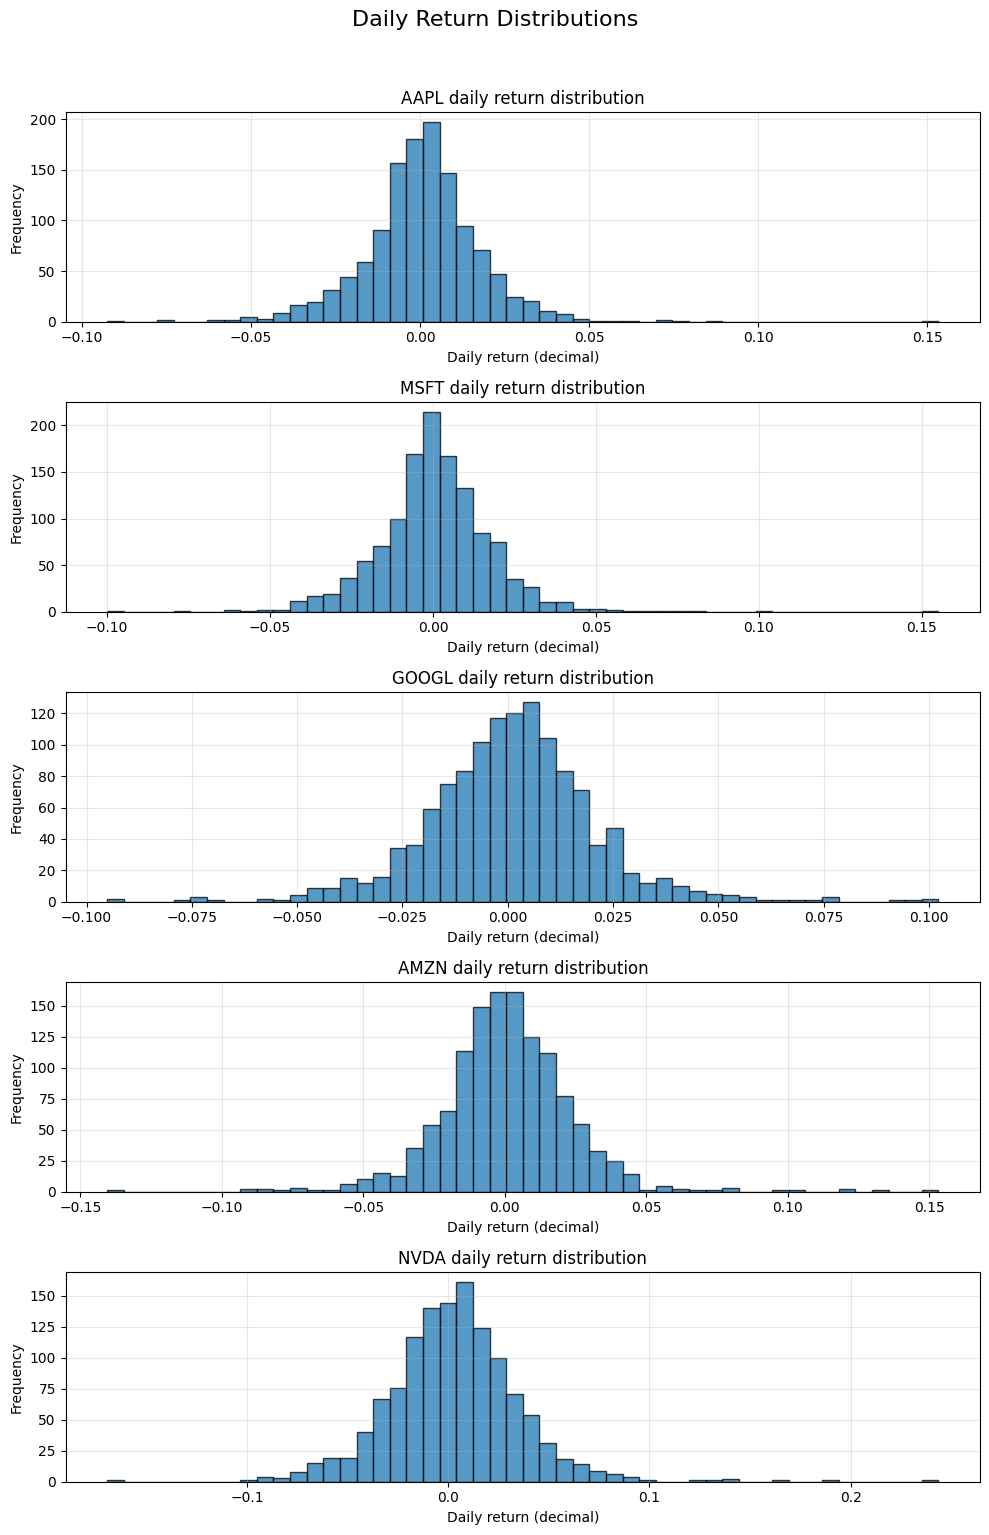

In [4]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(10, 15))
for ax, ticker in zip(axes, TICKERS):
    returns = return_data[ticker]["Daily Return"].dropna()
    ax.hist(returns, bins=50, alpha=0.75, edgecolor="black")
    ax.set_title(f"{ticker} daily return distribution")
    ax.set_xlabel("Daily return (decimal)")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)
fig.suptitle("Daily Return Distributions", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "performance_daily_returns_distribution.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

## Cumulative return over time

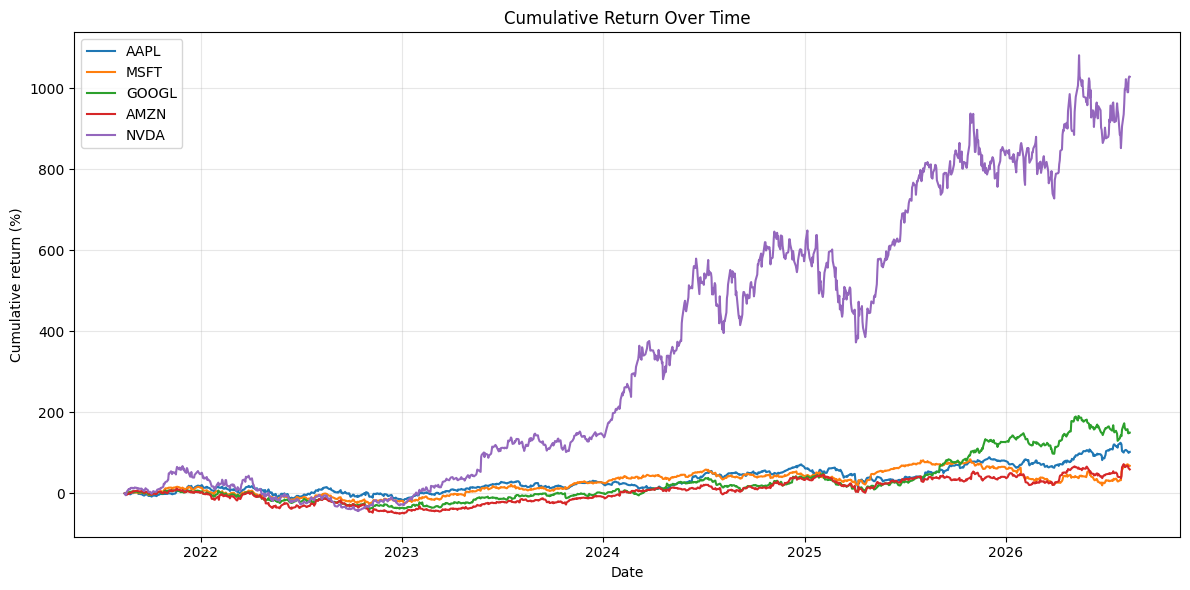

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
for ticker in TICKERS:
    cumulative_percent = return_data[ticker]["Cumulative Return"] * 100
    ax.plot(cumulative_percent.index, cumulative_percent, label=ticker)
ax.set_title("Cumulative Return Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return (%)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "performance_cumulative_returns.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

## Total return comparison

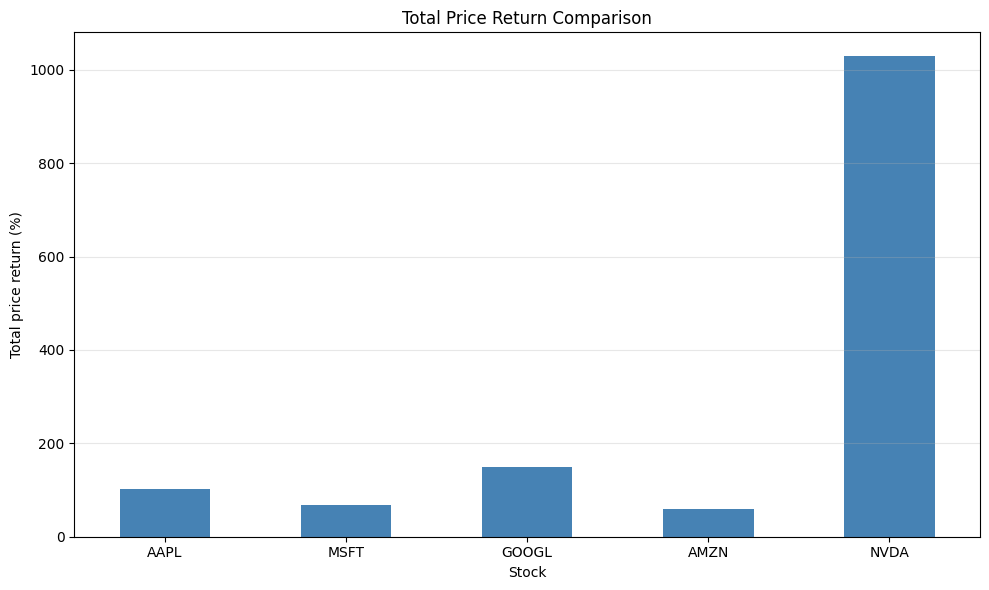

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
total_returns_percent = performance_summary["Total Price Return"] * 100
total_returns_percent.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Total Price Return Comparison")
ax.set_xlabel("Stock")
ax.set_ylabel("Total price return (%)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "performance_total_returns.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

## Key Observations

The following observations are generated directly from the calculated performance metrics. They describe historical performance only and are not investment recommendations.

In [7]:
highest_total_return = performance_summary["Cumulative Return"].idxmax()
lowest_total_return = performance_summary["Cumulative Return"].idxmin()
highest_average_daily_return = performance_summary["Average Daily Return"].idxmax()
best_single_day = performance_summary["Best Single-Day Return"].idxmax()
worst_single_day = performance_summary["Worst Single-Day Return"].idxmin()
print(f"Highest cumulative return: {highest_total_return}")
print(f"Lowest cumulative return: {lowest_total_return}")
print(f"Highest average daily return: {highest_average_daily_return}")
print(f"Largest single-day gain: {best_single_day}")
print(f"Largest single-day decline: {worst_single_day}")
print("These are historical performance observations, not investment recommendations.")

Highest cumulative return: NVDA
Lowest cumulative return: AMZN
Highest average daily return: NVDA
Largest single-day gain: NVDA
Largest single-day decline: NVDA
These are historical performance observations, not investment recommendations.
